# DeepFER: Facial Emotion Recognition Using Deep Learning

## Objective
To develop a deep learning-based facial emotion recognition system that classifies facial expressions into seven emotions: **Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise** using CNN and transfer learning techniques.

## Project Understanding
Facial Emotion Recognition (FER) is a computer vision task that identifies human emotions from facial expressions. This project uses image preprocessing, data augmentation, CNN-based deep learning, and model evaluation to build an effective emotion classification system.

## Business Objective
To develop an accurate and efficient emotion recognition solution that can support applications such as **Human-Computer Interaction, customer experience analysis, and real-time emotion-aware systems**.

## GitHub Repository
**Repository Link:** [DeepFER-Facial-Emotion-Recognition](https://github.com/Aks18had/DeepFER-Facial-Emotion-Recognition)

In [ ]:
from google.colab import drive # Mounting the Google Drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/DeepFER - Facial Emotion Recognition" # Giving the project path to colab

print("Project folders:")
print(os.listdir(project_path))

Project folders:
['01_Dataset', '02_Notebook', '03_Project_Report']


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/DeepFER - Facial Emotion Recognition/01_Dataset/Face Emotion Recognition Dataset.zip" # Giving data set path

print("Dataset exists:", os.path.exists(dataset_path))
print("File size:", round(os.path.getsize(dataset_path) / (1024**2), 2), "MB")

Dataset exists: True
File size: 120.5 MB


In [ ]:
import zipfile

with zipfile.ZipFile(dataset_path, 'r') as zip_ref: # Cheking zip file dataset structure
    files = zip_ref.namelist()

print("Total files/folders:", len(files))
print("\nFirst 20 entries:")
for item in files[:20]:
    print(item)

Total files/folders: 71774

First 20 entries:
images/images/train/angry/0.jpg
images/images/train/angry/1.jpg
images/images/train/angry/10.jpg
images/images/train/angry/10002.jpg
images/images/train/angry/10016.jpg
images/images/train/angry/10037.jpg
images/images/train/angry/10038.jpg
images/images/train/angry/10057.jpg
images/images/train/angry/10063.jpg
images/images/train/angry/10069.jpg
images/images/train/angry/10100.jpg
images/images/train/angry/10105.jpg
images/images/train/angry/10115.jpg
images/images/train/angry/10122.jpg
images/images/train/angry/10142.jpg
images/images/train/angry/1015.jpg
images/images/train/angry/10154.jpg
images/images/train/angry/10155.jpg
images/images/train/angry/10158.jpg
images/images/train/angry/1016.jpg


In [ ]:
from collections import Counter

top_levels = Counter(item.split('/')[0] for item in files)

print(top_levels)

Counter({'images': 71774})


In [ ]:
from collections import Counter

paths = [p for p in files if p.lower().endswith(".jpg")]

structure = Counter()

for p in paths:
    parts = p.split("/")
    if len(parts) >= 3:
        structure["/".join(parts[:3])] += 1

for folder, count in sorted(structure.items()):
    print(f"{folder}: {count} images")

images/images/train: 28821 images
images/images/validation: 7066 images
images/train/angry: 3993 images
images/train/disgust: 436 images
images/train/fear: 4103 images
images/train/happy: 7164 images
images/train/neutral: 4982 images
images/train/sad: 4938 images
images/train/surprise: 3205 images
images/validation/angry: 960 images
images/validation/disgust: 111 images
images/validation/fear: 1018 images
images/validation/happy: 1825 images
images/validation/neutral: 1216 images
images/validation/sad: 1139 images
images/validation/surprise: 797 images


In [ ]:
import zipfile # now we extract the zipfile of the dataset
import os

extract_path = "/content/deepfer_dataset"

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Contents:", os.listdir(extract_path))

Dataset extracted successfully.
Contents: ['images']


In [ ]:
# Dataset paths
base_path = "/content/deepfer_dataset/images"

train_path = os.path.join(base_path, "train")
validation_path = os.path.join(base_path, "validation")

print("Train path:", train_path)
print("Validation path:", validation_path)

Train path: /content/deepfer_dataset/images/train
Validation path: /content/deepfer_dataset/images/validation


Emotion Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total Training Images: 28821


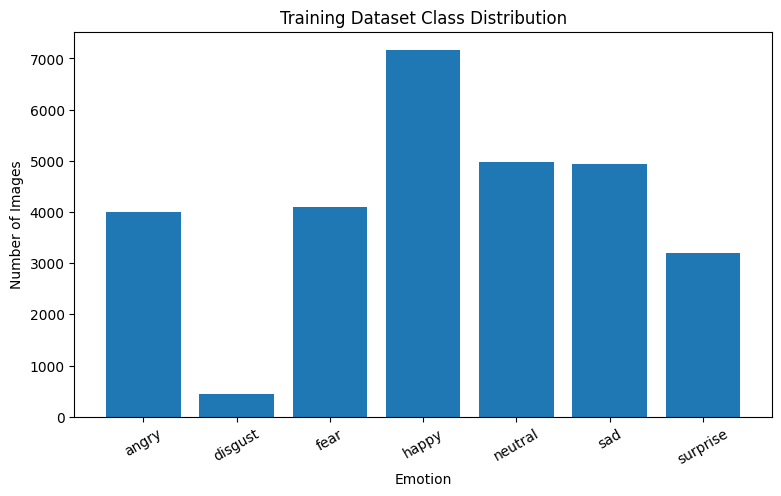

In [ ]:
import os
import matplotlib.pyplot as plt

classes = sorted(os.listdir(train_path))
class_counts = {
    cls: len(os.listdir(os.path.join(train_path, cls)))
    for cls in classes
}

print("Emotion Classes:", classes)
print("Total Training Images:", sum(class_counts.values()))

plt.figure(figsize=(9, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training Dataset Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

### Insight
The dataset contains **28,821 training images across 7 emotion classes**. The distribution is imbalanced, with **Happy** having the most images and **Disgust** having the fewest. This imbalance may affect model performance, particularly for minority classes, so it will be considered during model training.

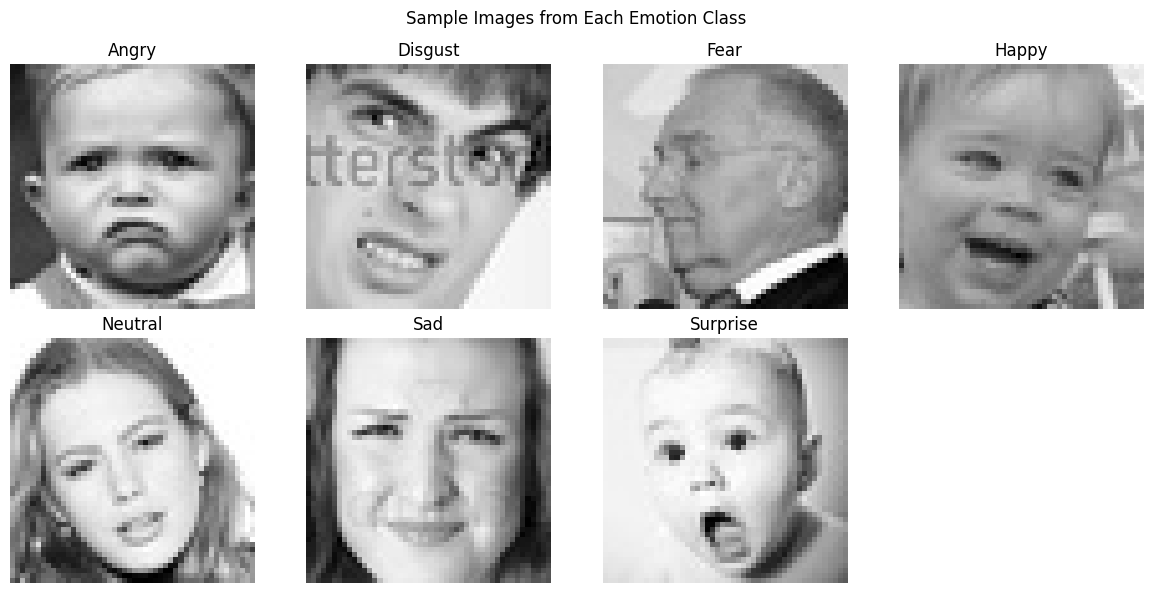

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i, emotion in enumerate(classes):
    image_file = random.choice(os.listdir(os.path.join(train_path, emotion)))
    image_path = os.path.join(train_path, emotion, image_file)

    image = Image.open(image_path)
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(emotion.capitalize())
    axes[i].axis("off")

axes[-1].axis("off")
plt.suptitle("Sample Images from Each Emotion Class")
plt.tight_layout()
plt.show()

### Insight
The sample images show noticeable variation in facial appearance and expressions across all seven classes. The images are grayscale and low-resolution, making subtle emotions such as **Fear, Disgust, and Sadness** more challenging to distinguish.

In [ ]:
from PIL import Image

invalid_images = []
image_sizes = set()
image_modes = set()
total_images = 0

for split_path in [train_path, validation_path]:
    for emotion in classes:
        folder = os.path.join(split_path, emotion)

        for file in os.listdir(folder):
            if file.lower().endswith(".jpg"):
                total_images += 1
                file_path = os.path.join(folder, file)

                try:
                    with Image.open(file_path) as img:
                        img.verify()

                    with Image.open(file_path) as img:
                        image_sizes.add(img.size)
                        image_modes.add(img.mode)

                except Exception:
                    invalid_images.append(file_path)

print("Total images checked:", total_images)
print("Invalid/Corrupt images:", len(invalid_images))
print("Image dimensions:", image_sizes)
print("Image modes:", image_modes)

Total images checked: 35887
Invalid/Corrupt images: 0
Image dimensions: {(48, 48)}
Image modes: {'L'}


### Insight
All **35,887 images passed the integrity check** with no corrupt files. Images are consistently **48×48 grayscale**, so no data cleaning is required.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (48, 48)
BATCH_SIZE = 128
SEED = 42

# Training: 90% train + 10% validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    subset="validation",
    shuffle=False,
    seed=SEED
)

# Final test set: existing validation folder
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    validation_path,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

Found 25942 images belonging to 7 classes.
Found 2879 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


### Data Preprocessing
Images are **rescaled to 0–1**, kept as **48×48 grayscale**, and labels are **one-hot encoded** for CNN training.



---


### Insight
Training data is augmented using **rotation, shifting, zoom, and flipping**, with separate **validation and test sets** for reliable evaluation.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(classes)),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:")
for emotion, weight in zip(classes, class_weights.values()):
    print(f"{emotion}: {weight:.2f}")

Class Weights:
angry: 1.03
disgust: 9.43
fear: 1.00
happy: 0.57
neutral: 0.83
sad: 0.83
surprise: 1.28


### Insight
**Class weights** are used to reduce the impact of class imbalance, giving greater importance to minority classes such as **Disgust** during training.

### What is CNN?
A **Convolutional Neural Network (CNN)** automatically learns visual features such as edges, shapes, and facial patterns from images, making it well-suited for **emotion recognition**.

### CNN Architecture
The model uses **3 convolution blocks** (Conv2D + Batch Normalization + MaxPooling + Dropout), followed by **Dense layers** and a **7-class Softmax output**.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(7, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,935 (2.61 MB)

 Trainable params: 684,231 (2.61 MB)

 Non-trainable params: 704 (2.75 KB)

### Insight
The CNN contains **684,935 parameters** and uses **Batch Normalization and Dropout** to improve learning stability and reduce overfitting.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    ModelCheckpoint(
        "best_cnn_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

print("Training callbacks configured successfully.")

Training callbacks configured successfully.


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 170s 822ms/step - accuracy: 0.1861 - loss: 2.2252 - val_accuracy: 0.0149 - val_loss: 7.3916 - learning_rate: 0.0010
Epoch 2/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 164s 808ms/step - accuracy: 0.2389 - loss: 1.9417 - val_accuracy: 0.1428 - val_loss: 2.1339 - learning_rate: 0.0010
Epoch 3/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 166s 818ms/step - accuracy: 0.2903 - loss: 1.7858 - val_accuracy: 0.2025 - val_loss: 2.0812 - learning_rate: 0.0010
Epoch 4/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 167s 821ms/step - accuracy: 0.3289 - loss: 1.6911 - val_accuracy: 0.3300 - val_loss: 1.6943 - learning_rate: 0.0010
Epoch 5/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 168s 829ms/step - accuracy: 0.3561 - loss: 1.6386 - val_accuracy: 0.2706 - val_loss: 1.8077 - learning_rate: 0.0010
Epoch 6/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 168s 825ms/step - accuracy: 0.3802 - loss: 1.5802 - val_accuracy: 0.4130 - val_loss: 1.5490 - learning_rate: 0.0010
Epoch 7/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 167s 820ms/step - accura

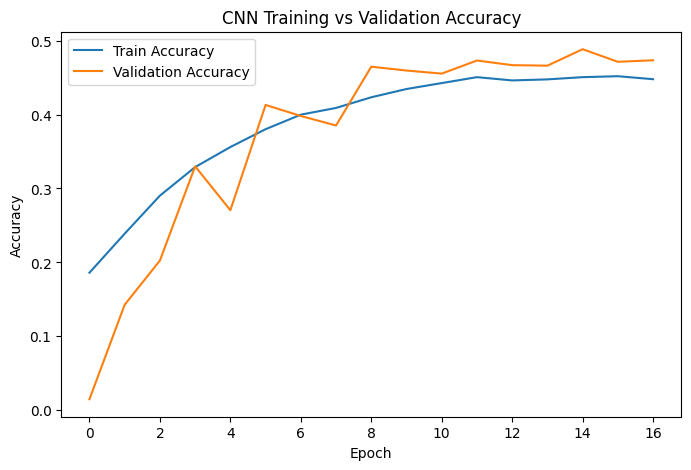

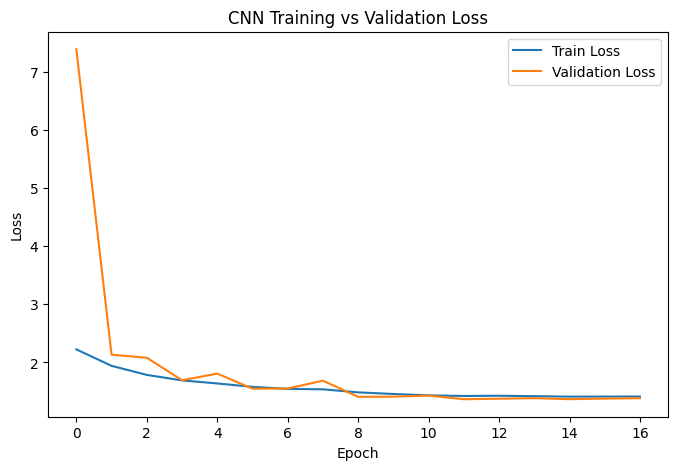

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Insight
The CNN shows **steady learning with decreasing loss**, while validation accuracy reaches about **49%** before Early Stopping.

56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.5038 - loss: 1.3185
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step

Test Accuracy: 0.5038

Classification Report:
              precision    recall  f1-score   support

       angry     0.4154    0.2917    0.3427       960
     disgust     0.1084    0.8108    0.1913       111
        fear     0.4012    0.1297    0.1960      1018
       happy     0.7342    0.7748    0.7539      1825
     neutral     0.4547    0.5938    0.5150      1216
         sad     0.4771    0.2924    0.3625      1139
    surprise     0.5769    0.7390    0.6480       797

    accuracy                         0.5038      7066
   macro avg     0.4526    0.5189    0.4299      7066
weighted avg     0.5258    0.5038    0.4927      7066



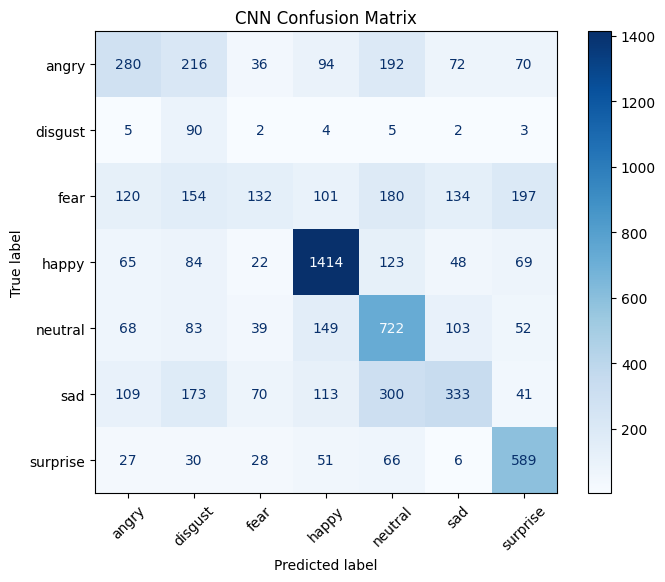

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(
    cmap="Blues", xticks_rotation=45, ax=plt.gca()
)
plt.title("CNN Confusion Matrix")
plt.show()

### Insight
The baseline CNN achieved **50.38% test accuracy**. Performance is stronger for **Happy**, while minority and visually similar emotions remain challenging.

### Transfer Learning
**MobileNetV2** is a lightweight pretrained CNN that uses learned visual features from ImageNet. We fine-tune its classification head for **7 facial emotion classes** to improve the baseline CNN performance efficiently.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

# Training: preprocessing + augmentation
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

tl_train = tl_train_datagen.flow_from_directory(
    train_path, target_size=(96, 96), color_mode="rgb",
    class_mode="categorical", batch_size=128,
    subset="training", shuffle=True, seed=42
)

# Validation: preprocessing only
tl_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.1
)

tl_val = tl_val_datagen.flow_from_directory(
    train_path, target_size=(96, 96), color_mode="rgb",
    class_mode="categorical", batch_size=128,
    subset="validation", shuffle=False, seed=42
)

# Test: preprocessing only
tl_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

tl_test = tl_test_datagen.flow_from_directory(
    validation_path, target_size=(96, 96), color_mode="rgb",
    class_mode="categorical", batch_size=128, shuffle=False
)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(7, activation="softmax")
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Transfer learning pipeline ready.")

Found 25942 images belonging to 7 classes.
Found 2879 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Transfer learning pipeline ready.


In [27]:
tl_callbacks = [
    ModelCheckpoint(
        "best_mobilenet_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-6
    )
]

tl_history = transfer_model.fit(
    tl_train,
    validation_data=tl_val,
    epochs=8,
    class_weight=class_weights,
    callbacks=tl_callbacks
)

Epoch 1/8
203/203 ━━━━━━━━━━━━━━━━━━━━ 197s 948ms/step - accuracy: 0.2649 - loss: 1.8592 - val_accuracy: 0.3633 - val_loss: 1.7036 - learning_rate: 0.0010
Epoch 2/8
203/203 ━━━━━━━━━━━━━━━━━━━━ 199s 936ms/step - accuracy: 0.3253 - loss: 1.7091 - val_accuracy: 0.3456 - val_loss: 1.6683 - learning_rate: 0.0010
Epoch 3/8
203/203 ━━━━━━━━━━━━━━━━━━━━ 188s 927ms/step - accuracy: 0.3428 - loss: 1.6638 - val_accuracy: 0.3755 - val_loss: 1.5995 - learning_rate: 0.0010
Epoch 4/8
203/203 ━━━━━━━━━━━━━━━━━━━━ 187s 922ms/step - accuracy: 0.3567 - loss: 1.6389 - val_accuracy: 0.3630 - val_loss: 1.6556 - learning_rate: 0.0010
Epoch 5/8
203/203 ━━━━━━━━━━━━━━━━━━━━ 187s 922ms/step - accuracy: 0.3720 - loss: 1.5948 - val_accuracy: 0.3932 - val_loss: 1.5658 - learning_rate: 2.0000e-04
Epoch 6/8
203/203 ━━━━━━━━━━━━━━━━━━━━ 189s 929ms/step - accuracy: 0.3766 - loss: 1.5740 - val_accuracy: 0.3880 - val_loss: 1.5674 - learning_rate: 2.0000e-04
Epoch 7/8
203/203 ━━━━━━━━━━━━━━━━━━━━ 194s 954ms/step - accur

### Transfer Learning Result
The frozen MobileNetV2 achieved a best validation accuracy of **39.87%**, which was lower than the baseline CNN.

### Insight
The pretrained features were not sufficiently adapted to this **facial emotion dataset**, so we will use **limited fine-tuning** to improve the model.

In [28]:
# Fine-tune only the last 20 layers
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep Batch Normalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Trainable layers: 13


### Fine-Tuning
Only the final **13 MobileNetV2 layers** were selected for fine-tuning while keeping the remaining pretrained layers frozen.

### Insight
The frozen MobileNetV2 underperformed the CNN baseline, so the **CNN remains our current best model**.

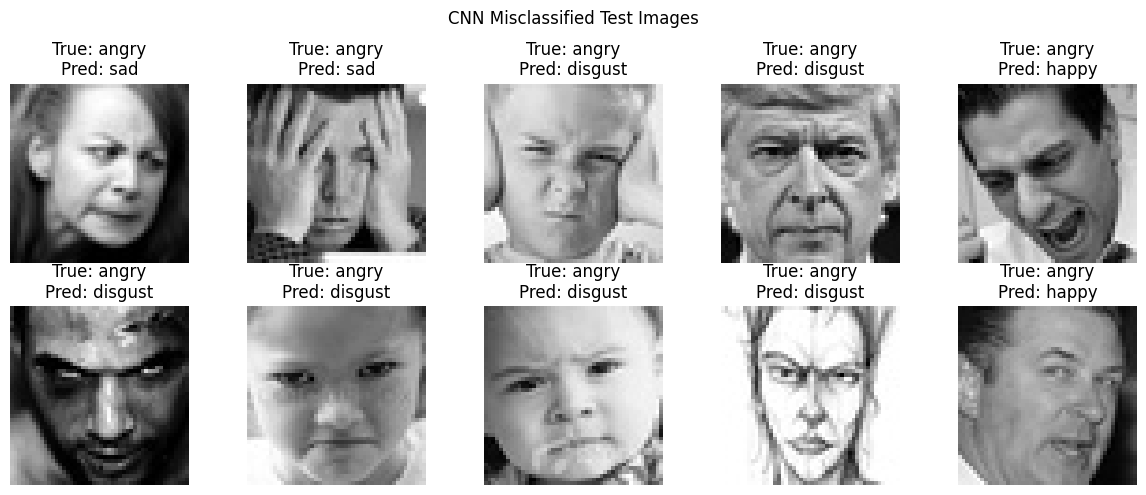

In [29]:
# Show misclassified test images
test_generator.reset()
predictions = model.predict(test_generator, verbose=0)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

misclassified = np.where(y_pred != y_true)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.ravel(), misclassified[:10]):
    image_path = test_generator.filepaths[idx]
    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"True: {classes[y_true[idx]]}\nPred: {classes[y_pred[idx]]}")
    ax.axis("off")

plt.suptitle("CNN Misclassified Test Images")
plt.tight_layout()
plt.show()

### Error Analysis Insight
The misclassified samples show strong overlap between **Angry, Sad, and Disgust**, indicating that subtle facial expressions are difficult to distinguish in low-resolution grayscale images.

In [30]:
# Evaluate the trained frozen MobileNetV2 model on the test set

tl_test_loss, tl_test_accuracy = transfer_model.evaluate(tl_test, verbose=1)

tl_test.reset()
tl_predictions = transfer_model.predict(tl_test, verbose=1)

tl_y_pred = np.argmax(tl_predictions, axis=1)
tl_y_true = tl_test.classes

print(f"\nMobileNetV2 Test Accuracy: {tl_test_accuracy:.4f}")
print("\nMobileNetV2 Classification Report:")
print(classification_report(
    tl_y_true,
    tl_y_pred,
    target_names=classes,
    digits=4
))

56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 715ms/step - accuracy: 0.4070 - loss: 1.5492
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 716ms/step

MobileNetV2 Test Accuracy: 0.4070

MobileNetV2 Classification Report:
              precision    recall  f1-score   support

       angry     0.2926    0.4135    0.3427       960
     disgust     0.1123    0.4595    0.1805       111
        fear     0.3990    0.0756    0.1272      1018
       happy     0.5020    0.6729    0.5750      1825
     neutral     0.5357    0.1604    0.2468      1216
         sad     0.3298    0.4864    0.3930      1139
    surprise     0.6538    0.4693    0.5464       797

    accuracy                         0.4070      7066
   macro avg     0.4036    0.3911    0.3445      7066
weighted avg     0.4478    0.4070    0.3837      7066



## Model Comparison

| Model | Test Accuracy | Macro F1 |
|---|---:|---:|
| **Custom CNN** | **50.38%** | **42.99%** |
| MobileNetV2 (Frozen) | 40.70% | 34.45% |

### Insight
The **custom CNN outperformed the frozen MobileNetV2** on the test set. For this low-resolution grayscale dataset, the task-specific CNN was more effective than directly using ImageNet-pretrained features.

In [32]:
# Created a dedicated model folder and save the final CNN model

model_path = "/content/drive/MyDrive/DeepFER - Facial Emotion Recognition/04_Model"

os.makedirs(model_path, exist_ok=True)

final_model_path = os.path.join(
    model_path,
    "DeepFER_CNN_Final.keras"
)

model.save(final_model_path)

print("Model folder created successfully.")
print("Final CNN model saved at:")
print(final_model_path)

Model folder created successfully.
Final CNN model saved at:
/content/drive/MyDrive/DeepFER - Facial Emotion Recognition/04_Model/DeepFER_CNN_Final.keras


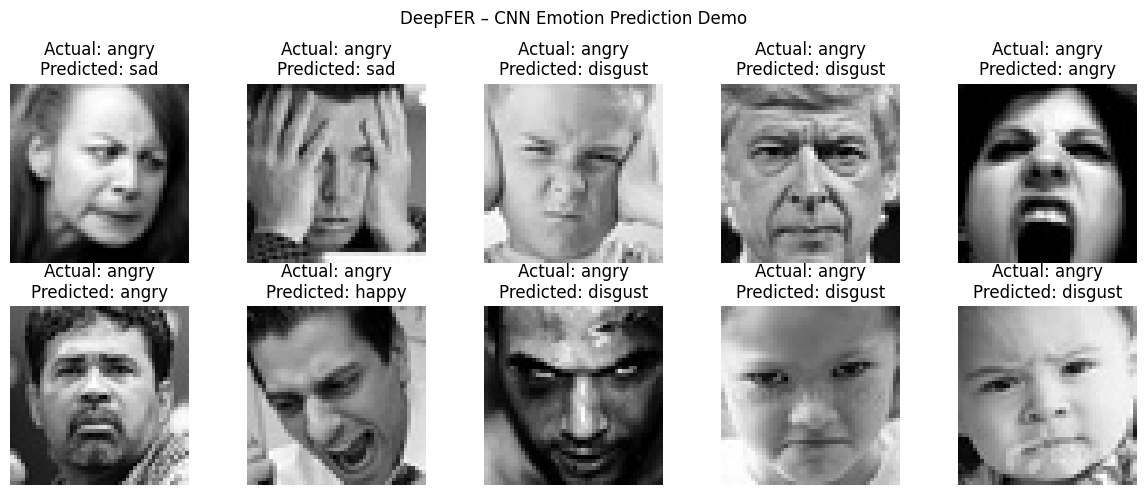

In [33]:
# Visual prediction demo on unseen test images

test_generator.reset()
images, labels = next(test_generator)

predictions = model.predict(images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(labels, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(
        f"Actual: {classes[actual_classes[i]]}\n"
        f"Predicted: {classes[predicted_classes[i]]}"
    )
    ax.axis("off")

plt.suptitle("DeepFER – CNN Emotion Prediction Demo")
plt.tight_layout()
plt.show()

### Prediction Demo Insight
The CNN correctly identifies some strong facial expressions, while subtle expressions such as **Angry and Disgust** are frequently confused. This reflects the challenge of emotion recognition from **low-resolution grayscale images**.

In [34]:
# Verify final model file

print("Model exists:", os.path.exists(final_model_path))

if os.path.exists(final_model_path):
    print("Model size:", round(os.path.getsize(final_model_path) / (1024**2), 2), "MB")

Model exists: True
Model size: 7.91 MB


## Real-Time Emotion Recognition

The final CNN can be integrated with a real-time camera pipeline using **OpenCV**. The process is:

**Camera Frame → Face Detection → Face Cropping → Resize to 48×48 → Grayscale & Normalization → CNN Prediction → Emotion Label**

The system can be applied to **human-computer interaction, customer experience analysis, and emotion-aware applications**.

### Practical Considerations
Real-world performance may be affected by **lighting conditions, face orientation, image quality, occlusion, and subtle emotional expressions**.

## Feature Engineering & Selection

For image-based emotion recognition, handcrafted numerical features were not required. Instead, the CNN automatically learns **hierarchical visual features** such as edges, facial shapes, textures, and expression patterns through convolutional layers.

The selected transformations — **48×48 grayscale representation, normalization, resizing, and data augmentation** — were chosen to preserve facial-expression information while reducing computational complexity.

### Insight
The CNN performs **automatic feature learning**, making manual feature extraction and feature selection unnecessary for the final model.

## Learnings & Conclusion

### Key Learnings
- CNNs can automatically learn meaningful **facial features and expression patterns** from images.
- **Data augmentation, class weighting, Dropout, Batch Normalization, Early Stopping, and learning-rate reduction** helped build a more robust training pipeline.
- The **custom CNN outperformed frozen MobileNetV2** on this dataset, showing that a task-specific architecture can be effective for low-resolution grayscale images.
- Error analysis showed that **Angry, Disgust, Fear, and Sad** are more difficult to distinguish due to visual similarity.

### Conclusion
DeepFER successfully developed a **7-class facial emotion recognition system** using a custom CNN. The final CNN achieved **50.38% test accuracy with a 42.99% macro F1-score**. While performance is affected by class imbalance and low-resolution images, the project demonstrates a complete workflow from **data preparation and preprocessing to model development, evaluation, error analysis, and real-time application design**.

Future improvements can include **higher-resolution data, stronger architectures, improved class balancing, and fine-tuning pretrained models**.